# Phase 2: Market Segmentation via Clustering

In this notebook, you will:
1. Apply K-Means clustering to segment properties into market tiers
2. Use Hierarchical clustering and create dendrograms
3. Implement DBSCAN for density-based property grouping
4. Apply PCA for dimensionality reduction and visualization
5. Determine optimal clusters using Elbow method and Silhouette score
6. Interpret and visualize market segments

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '..')
from src.data_loader import load_housing_data, preprocess_features
from src.clustering import *

## 1. Data Preparation

In [2]:
df = load_housing_data()
X_scaled, y, feature_names, scaler = preprocess_features(df)
print(f"Features shape: {X_scaled.shape}")
print(f"Feature names: {feature_names}")

Features shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 2. K-Means Clustering

### Finding Optimal K

In [3]:
# TODO: Use find_optimal_k() and plot:
# - Elbow curve (inertia vs k)
# - Silhouette score vs k
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_optimal_k(X, k_range=range(2, 11), random_state=42):
    inertia_values = []
    silhouette_values = []

    for k in k_range:
        kmeans = KMeans(
            n_clusters=k,
            random_state=random_state,
            n_init=10
        )

        labels = kmeans.fit_predict(X)

        inertia_values.append(kmeans.inertia_)
        silhouette_values.append(silhouette_score(X, labels))

    results = {
        "k_values": list(k_range),
        "inertia": inertia_values,
        "silhouette_scores": silhouette_values
    }

    return results

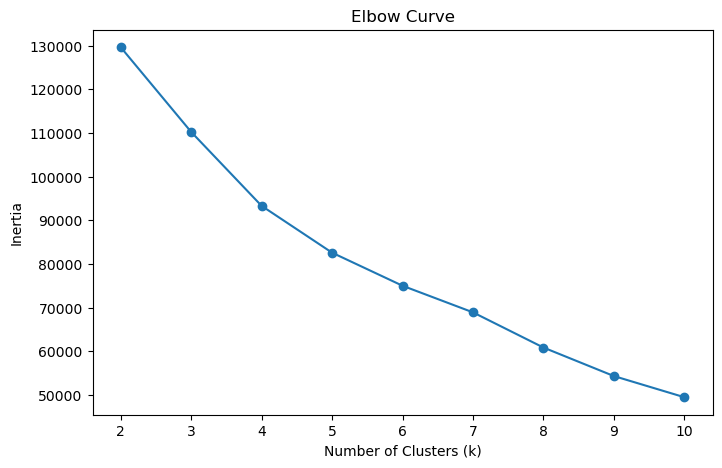

In [4]:
# Run optimal k search
k_results = find_optimal_k(X_scaled, k_range=range(2, 11))

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_results["k_values"], k_results["inertia"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.show()

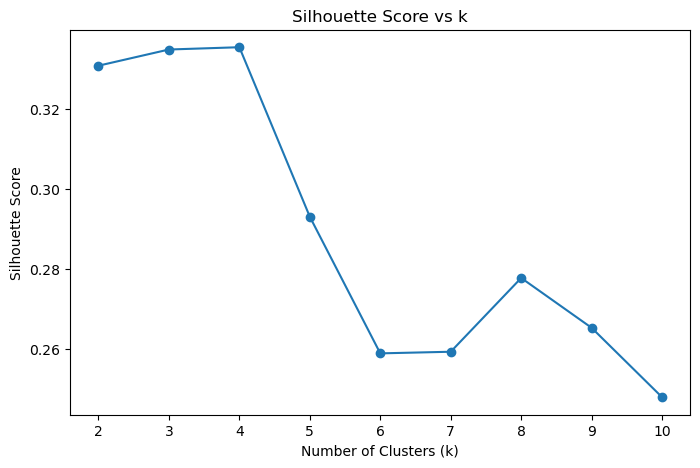

In [5]:
# Plot Silhouette Score
plt.figure(figsize=(8, 5))
plt.plot(k_results["k_values"], k_results["silhouette_scores"], marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

In [6]:
# Best k based on silhouette score
best_k = k_results["k_values"][
    k_results["silhouette_scores"].index(max(k_results["silhouette_scores"]))
]

print("Best k based on silhouette score:", best_k)

Best k based on silhouette score: 4


In [7]:
# TODO: Perform K-Means with optimal k using perform_kmeans()
# Analyze cluster characteristics
from sklearn.cluster import KMeans

def perform_kmeans(X, k, random_state=42):
    """
    Perform K-Means clustering.

    Returns:
        model: fitted KMeans model
        labels: cluster labels
    """
    kmeans = KMeans(
        n_clusters=k,
        random_state=random_state,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    return kmeans, labels

In [8]:
# Perform K-Means using optimal k
kmeans_model, cluster_labels = perform_kmeans(X_scaled, best_k)

# Add cluster labels to original dataframe
df_clustered = df.copy()
df_clustered["Cluster"] = cluster_labels

df_clustered.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Cluster
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0


In [9]:
# Analyze cluster characteristics
cluster_summary = df_clustered.groupby("Cluster").mean(numeric_only=True)

cluster_summary

# Count records in each cluster
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

cluster_counts
# Optional: combine count + numeric summary
cluster_profile = cluster_summary.copy()
cluster_profile["Count"] = cluster_counts

cluster_profile

# Optional: view cluster centers
cluster_centers = pd.DataFrame(
    kmeans_model.cluster_centers_,
    columns=X_scaled.columns if hasattr(X_scaled, "columns") else [f"Feature_{i}" for i in range(X_scaled.shape[1])]
)

cluster_centers

,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7
0,-0.035023,0.030792,0.030109,-0.031072,-0.123052,-0.023677,1.085326,-1.078312
1,0.026590,-0.017584,-0.089669,-0.052390,0.094210,-0.001387,-0.790903,0.779119
2,1.473189,1.088087,0.148127,-0.004321,4.095474,74.983717,1.116534,-0.745516
3,-0.261764,-0.787124,10.799985,11.911303,-1.001485,-0.055168,0.973019,0.080579


## 3. Hierarchical Clustering

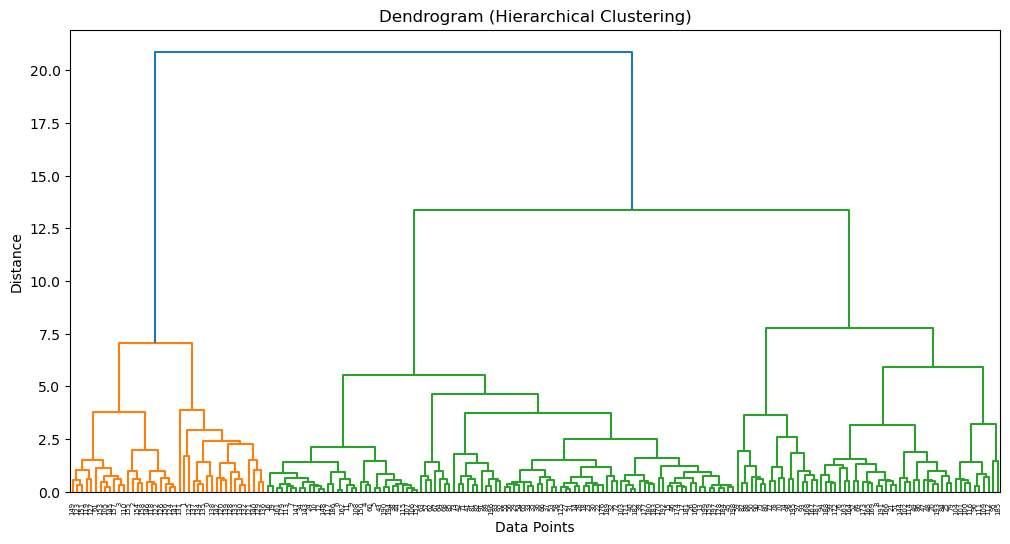

In [10]:
# TODO: Compute linkage matrix and plot dendrogram
# Use a subset for visualization (e.g., first 200 samples)
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

# Use subset for visualization (first 200 samples)
X_subset = X_scaled[:200]

# Compute linkage matrix
linkage_matrix = linkage(X_subset, method='ward')  # 'ward' is most common

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()



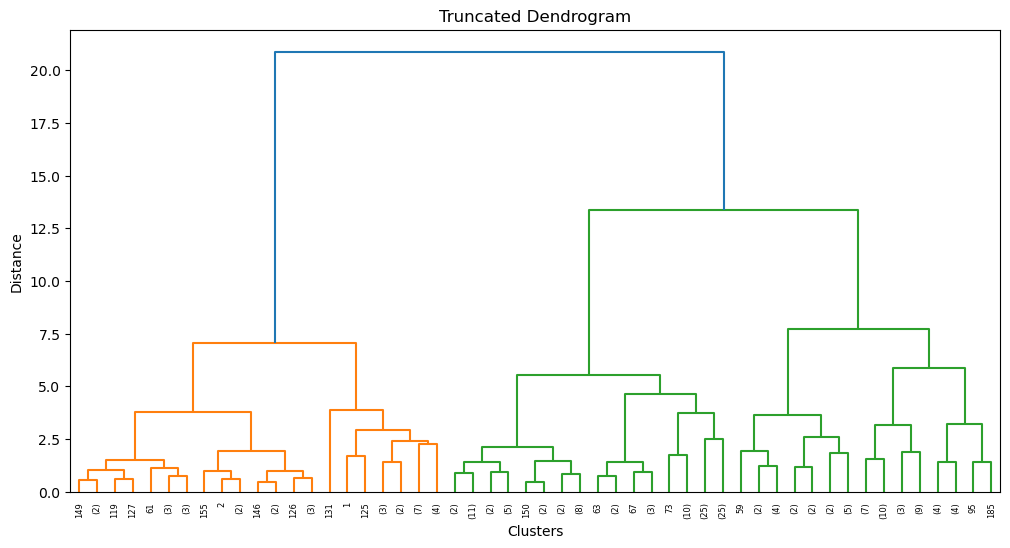

In [11]:
plt.figure(figsize=(12, 6))
dendrogram(
    linkage_matrix,
    truncate_mode='level',  # limits tree depth
    p=5
)
plt.title("Truncated Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

In [12]:
# TODO: Perform hierarchical clustering
# Compare with K-Means results
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
import pandas as pd

# Perform Hierarchical Clustering using same best_k from K-Means
hierarchical_model = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = hierarchical_model.fit_predict(X_scaled)

# Add labels to dataframe
df_compare = df.copy()
df_compare["KMeans_Cluster"] = cluster_labels
df_compare["Hierarchical_Cluster"] = hierarchical_labels

df_compare.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,KMeans_Cluster,Hierarchical_Cluster
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,0,2
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,0,2
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,0,2
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,0,2
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,0,2


In [13]:
# Compare silhouette scores
kmeans_silhouette = silhouette_score(X_scaled, cluster_labels)
hierarchical_silhouette = silhouette_score(X_scaled, hierarchical_labels)

comparison_results = pd.DataFrame({
    "Model": ["K-Means", "Hierarchical Clustering"],
    "Silhouette Score": [kmeans_silhouette, hierarchical_silhouette]
})

comparison_results

,Model,Silhouette Score
0,K-Means,0.335469
1,Hierarchical Clustering,0.323229


In [14]:
# Compare cluster sizes
kmeans_counts = pd.Series(cluster_labels).value_counts().sort_index()
hierarchical_counts = pd.Series(hierarchical_labels).value_counts().sort_index()

cluster_size_comparison = pd.DataFrame({
    "KMeans_Count": kmeans_counts,
    "Hierarchical_Count": hierarchical_counts
})

cluster_size_comparison

# Optional: Compare similarity between K-Means and Hierarchical labels
ari_score = adjusted_rand_score(cluster_labels, hierarchical_labels)

print("Adjusted Rand Index:", ari_score)

Adjusted Rand Index: 0.8038146047325399


In [15]:
# Analyze hierarchical cluster characteristics
df_hierarchical = df.copy()
df_hierarchical["Cluster"] = hierarchical_labels

hierarchical_summary = df_hierarchical.groupby("Cluster").mean(numeric_only=True)

hierarchical_summary

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
Cluster,,,,,,,,,
0,3.935994,28.192973,5.217788,1.065418,1537.071667,3.081337,34.164741,-118.197095,2.101582
1,3.364109,18.786667,32.165032,6.735987,284.813333,2.502471,37.751467,-119.439333,1.634013
2,3.764711,29.481158,5.522474,1.094074,1247.206155,2.753612,38.076698,-121.878005,2.017374
3,6.669400,42.333333,5.795482,1.094628,6063.333333,781.836386,38.016667,-121.063333,1.850000


## 4. DBSCAN Clustering

In [16]:
# TODO: Tune DBSCAN parameters using tune_dbscan()
# Find best eps and min_samples

def tune_dbscan(X, eps_values, min_samples_values):
    results = []

    for eps in eps_values:
        for min_samples in min_samples_values:
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X)

            # Ignore cases where all points are noise or one cluster
            unique_labels = set(labels)
            if len(unique_labels) <= 1 or (-1 in unique_labels and len(unique_labels) == 2):
                continue

            try:
                score = silhouette_score(X, labels)
            except:
                score = -1

            results.append({
                "eps": eps,
                "min_samples": min_samples,
                "silhouette_score": score,
                "num_clusters": len(set(labels)) - (1 if -1 in labels else 0),
                "noise_points": list(labels).count(-1)
            })

    return pd.DataFrame(results).sort_values(by="silhouette_score", ascending=False)

In [18]:
eps_range = np.arange(0.1, 2.0, 0.2)
min_samples_range = range(3, 10)

dbscan_results = tune_dbscan(X_scaled, eps_range, min_samples_range)

dbscan_results.head()

,eps,min_samples,silhouette_score,num_clusters,noise_points
40,1.5,5,0.766764,2,112
48,1.9,9,0.763763,2,82
44,1.7,6,0.762760,2,91
47,1.9,8,0.759388,2,76
45,1.9,3,0.756373,3,51


In [19]:
best_params = dbscan_results.iloc[0]

best_eps = best_params["eps"]
best_min_samples = best_params["min_samples"]

print("Best eps:", best_eps)
print("Best min_samples:", best_min_samples)

Best eps: 1.5000000000000004
Best min_samples: 5.0


In [23]:
from sklearn.cluster import DBSCAN

# Convert values to correct types
best_eps = float(best_eps)
best_min_samples = int(best_min_samples)

dbscan_model = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

print("DBSCAN completed successfully")
print(set(dbscan_labels))

best_params = dbscan_results.iloc[0]

best_eps = float(best_params["eps"])
best_min_samples = int(best_params["min_samples"])

DBSCAN completed successfully
{0, 1, -1}


In [24]:
dbscan_model = DBSCAN(eps=best_eps, min_samples=best_min_samples)
dbscan_labels = dbscan_model.fit_predict(X_scaled)

In [25]:
dbscan_results.head()

,eps,min_samples,silhouette_score,num_clusters,noise_points
40,1.5,5,0.766764,2,112
48,1.9,9,0.763763,2,82
44,1.7,6,0.762760,2,91
47,1.9,8,0.759388,2,76
45,1.9,3,0.756373,3,51


In [26]:
# TODO: Run DBSCAN with best parameters
# Analyze noise points and clusters

# Run DBSCAN with best parameters
dbscan_model = DBSCAN(
    eps=best_eps,
    min_samples=int(best_min_samples)
)

dbscan_labels = dbscan_model.fit_predict(X_scaled)

# Add DBSCAN labels to original dataframe
df_dbscan = df.copy()
df_dbscan["DBSCAN_Cluster"] = dbscan_labels

df_dbscan.head()

# Analyze cluster counts including noise
cluster_counts = df_dbscan["DBSCAN_Cluster"].value_counts().sort_index()

cluster_counts

DBSCAN_Cluster
-1      112
 0    20523
 1        5
Name: count, dtype: int64

In [27]:
# Count noise points
noise_points = (df_dbscan["DBSCAN_Cluster"] == -1).sum()
total_points = len(df_dbscan)
noise_percentage = (noise_points / total_points) * 100

print("Noise Points:", noise_points)
print("Noise Percentage:", round(noise_percentage, 2), "%")

# Number of actual clusters excluding noise (-1)
num_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)

print("Number of clusters:", num_clusters)

# Analyze cluster characteristics excluding noise
cluster_summary = (
    df_dbscan[df_dbscan["DBSCAN_Cluster"] != -1]
    .groupby("DBSCAN_Cluster")
    .mean(numeric_only=True)
)

cluster_summary

Noise Points: 112
Noise Percentage: 0.54 %
Number of clusters: 2


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
DBSCAN_Cluster,,,,,,,,,
0,3.867772,28.692735,5.329957,1.075727,1417.955465,2.932242,35.624573,-119.570025,2.0696
1,3.526280,12.400000,28.715071,5.293304,195.200000,2.022927,38.788000,-120.360000,1.3664


In [28]:
# View noise records separately
noise_data = df_dbscan[df_dbscan["DBSCAN_Cluster"] == -1]

noise_data.head()

# Optional: Compare DBSCAN with KMeans and Hierarchical
from sklearn.metrics import silhouette_score

if num_clusters > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    print("DBSCAN Silhouette Score:", dbscan_silhouette)
else:
    print("Silhouette score cannot be calculated because DBSCAN found fewer than 2 clusters.")

DBSCAN Silhouette Score: 0.7667640061542819


## 5. PCA & Visualization

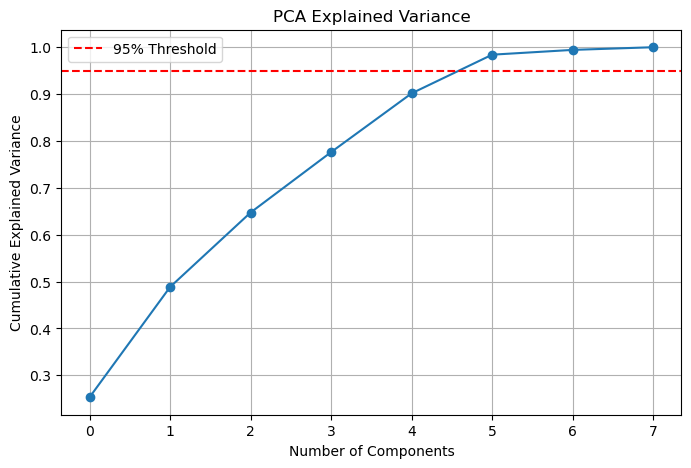

In [29]:
# TODO: Perform PCA and plot explained variance
# Find optimal number of components for 95% variance

from sklearn.decomposition import PCA


# Fit PCA on scaled data
pca = PCA()
pca.fit(X_scaled)

# Explained variance ratio
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend()
plt.grid()
plt.show()

In [30]:
# Find number of components for 95% variance
optimal_components = np.argmax(cumulative_variance >= 0.95) + 1

print("Optimal number of components for 95% variance:", optimal_components)

pca_optimal = PCA(n_components=optimal_components)
X_pca = pca_optimal.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)

Optimal number of components for 95% variance: 6
Reduced shape: (20640, 6)


In [31]:
# TODO: Use cluster_with_pca() for 2D visualization
# Create scatter plot colored by cluster labels

from sklearn.decomposition import PCA

def cluster_with_pca(X, n_components=2):
    """
    Reduce data to 2D using PCA

    Returns:
        X_pca: transformed 2D data
        pca: fitted PCA model
    """
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    return X_pca, pca

X_pca_2d, pca_model = cluster_with_pca(X_scaled, n_components=2)

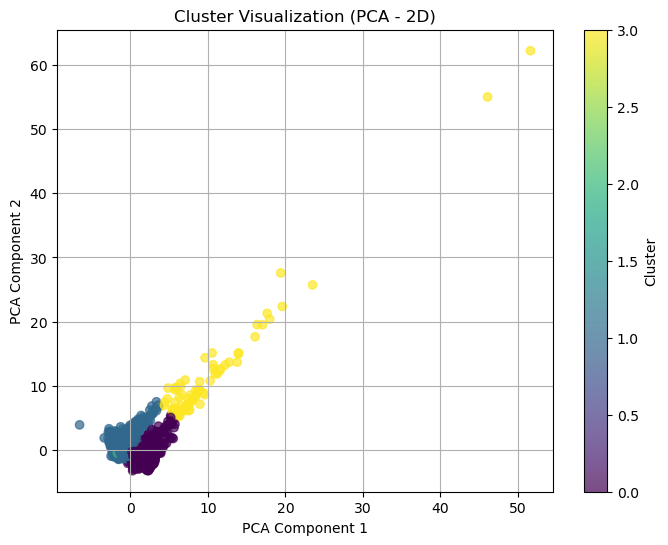

In [32]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=cluster_labels,   # or dbscan_labels / hierarchical_labels
    cmap='viridis',
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Cluster Visualization (PCA - 2D)")
plt.colorbar(scatter, label="Cluster")
plt.grid()
plt.show()

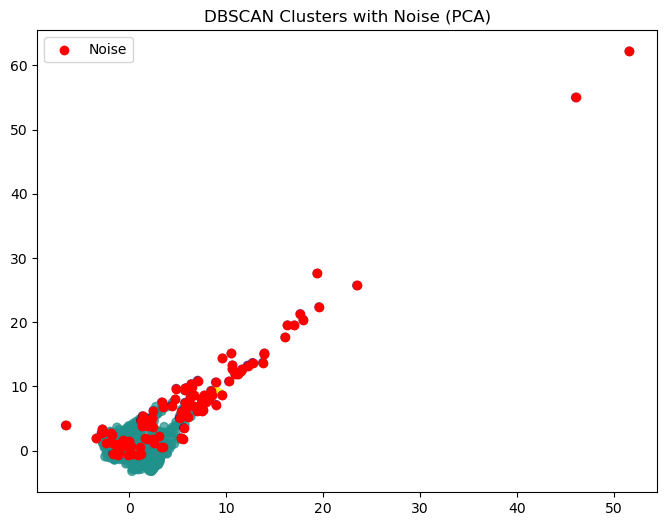

In [33]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    alpha=0.7
)

# Highlight noise points in red
noise_mask = (dbscan_labels == -1)
plt.scatter(
    X_pca_2d[noise_mask, 0],
    X_pca_2d[noise_mask, 1],
    color='red',
    label='Noise'
)

plt.legend()
plt.title("DBSCAN Clusters with Noise (PCA)")
plt.show()

## 6. Cluster Interpretation

TODO: For each cluster, analyze:
- Average feature values
- Price distribution
- Geographic distribution
- What "market tier" does each cluster represent?

In [34]:
# TODO: Create cluster profile analysis
df_clustered = df.copy()
df_clustered["Cluster"] = cluster_labels  # or dbscan_labels / hierarchical_labels

cluster_profile = df_clustered.groupby("Cluster").mean(numeric_only=True)

cluster_profile

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
Cluster,,,,,,,,,
0,3.804135,29.027008,5.503493,1.081950,1286.128086,2.824753,37.950009,-121.730083,1.973423
1,3.921187,28.418182,5.207149,1.071848,1532.163469,3.056250,33.942571,-118.008752,2.140146
2,6.669400,42.333333,5.795482,1.094628,6063.333333,781.836386,38.016667,-121.063333,1.850000
3,3.373379,18.733333,32.149384,6.741434,291.360000,2.497688,37.710133,-119.408267,1.628373


In [35]:
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()

cluster_profile["Count"] = cluster_counts

cluster_profile

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,Count
Cluster,,,,,,,,,,
0,3.804135,29.027008,5.503493,1.081950,1286.128086,2.824753,37.950009,-121.730083,1.973423,8627
1,3.921187,28.418182,5.207149,1.071848,1532.163469,3.056250,33.942571,-118.008752,2.140146,11935
2,6.669400,42.333333,5.795482,1.094628,6063.333333,781.836386,38.016667,-121.063333,1.850000,3
3,3.373379,18.733333,32.149384,6.741434,291.360000,2.497688,37.710133,-119.408267,1.628373,75


In [36]:
cluster_detailed = df_clustered.groupby("Cluster").agg(['mean', 'median', 'std'])

cluster_detailed


cluster_normalized = cluster_profile.drop(columns="Count")
cluster_normalized = (cluster_normalized - cluster_normalized.mean()) / cluster_normalized.std()

cluster_normalized

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
Cluster,,,,,,,,,
0,-0.424275,-0.061990,-0.499810,-0.500301,-0.391875,-0.499918,0.528066,-1.000815,0.350050
1,-0.346421,-0.124792,-0.522048,-0.503871,-0.296142,-0.499324,-1.496679,1.219406,1.123694
2,1.481477,1.310589,-0.477898,-0.495820,1.466962,1.500000,0.561744,-0.603019,-0.222667
3,-0.710781,-1.123807,1.499756,1.499992,-0.778945,-0.500758,0.406869,0.384428,-1.251078


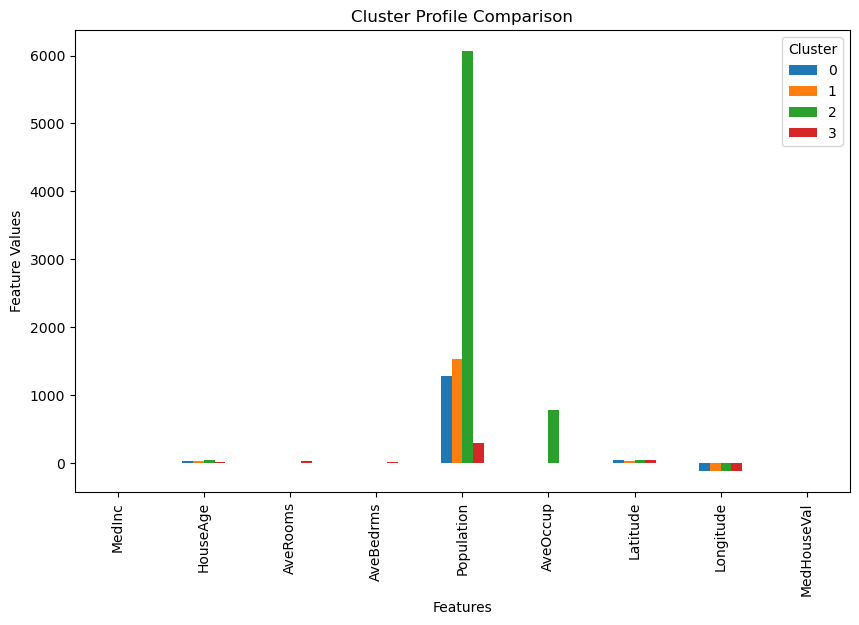

In [37]:
cluster_profile.drop(columns="Count").T.plot(kind='bar', figsize=(10,6))
plt.title("Cluster Profile Comparison")
plt.ylabel("Feature Values")
plt.xlabel("Features")
plt.legend(title="Cluster")
plt.show()

In [38]:
cluster_profile_dbscan = (
    df_clustered[df_clustered["Cluster"] != -1]
    .groupby("Cluster")
    .mean(numeric_only=True)
)

## Summary

TODO: Write a summary:
- Which clustering algorithm worked best for this data?
- How many natural market segments exist?
- What characterizes each segment?
- How did PCA help with visualization?